# Evaluation: Confusion Matrix and ROC Curves

In [1]:
# Import
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, RocCurveDisplay, precision_recall_curve

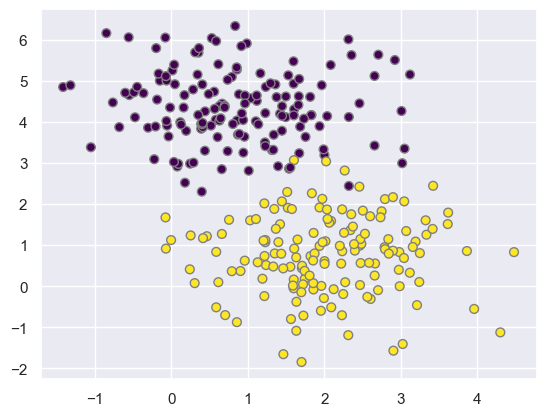

In [2]:
# Generate some data
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=400, centers=2,
                       cluster_std=.90, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Plot
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=40, cmap='viridis', edgecolors='gray');

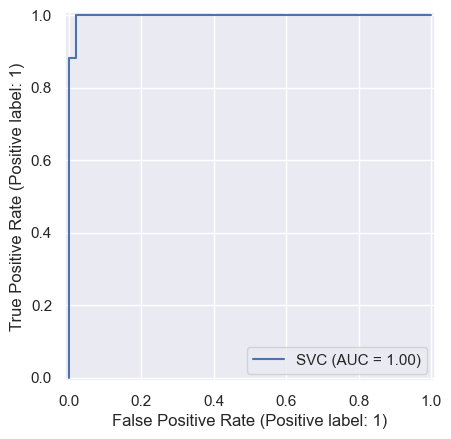

In [3]:
from sklearn.metrics import roc_curve, RocCurveDisplay

# Train some classifier
model = SVC(kernel='linear').fit(X_train, y_train)
y_score = model.decision_function(X_test)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
RocCurveDisplay.from_estimator(model, X_test, y_test);

In [4]:
fpr

array([0.        , 0.        , 0.        , 0.02040816, 0.02040816,
       1.        ])

In [5]:
tpr

array([0.        , 0.01960784, 0.88235294, 0.88235294, 1.        ,
       1.        ])

In [6]:
thresholds

array([        inf, 10.06341163,  1.69476686,  1.53718114,  0.05090405,
       -8.88444776])

## ROC Curves in `sklearn`: a G'fühl griang

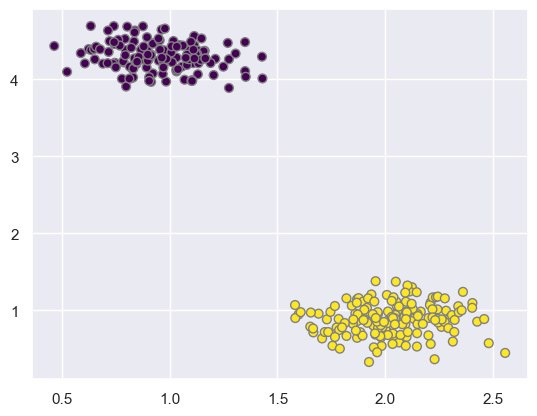

<Figure size 640x480 with 0 Axes>

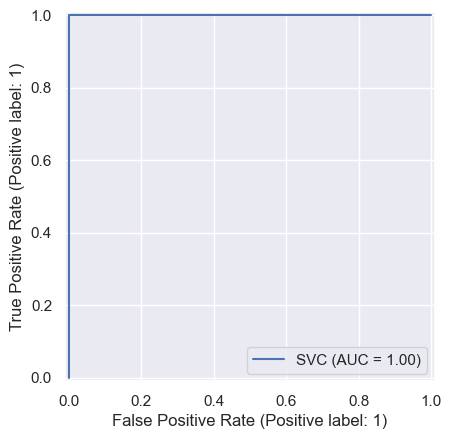

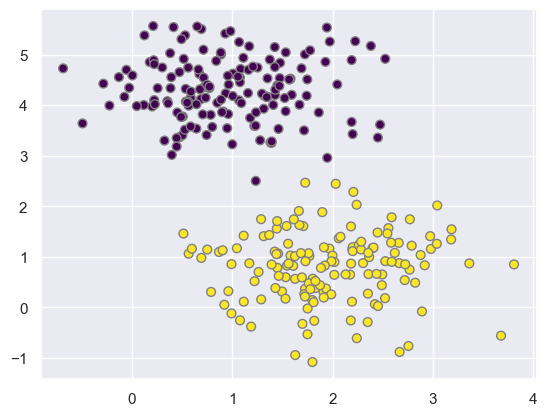

<Figure size 640x480 with 0 Axes>

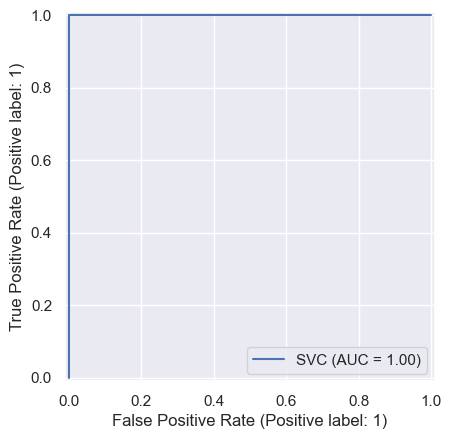

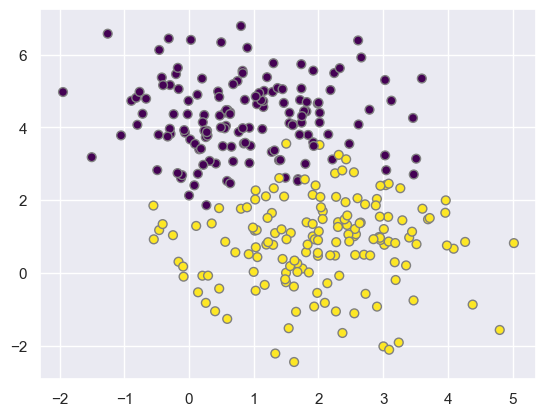

<Figure size 640x480 with 0 Axes>

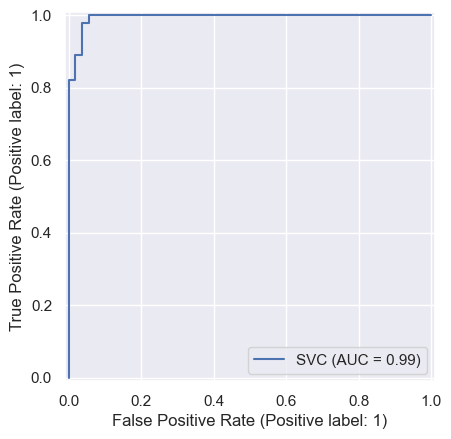

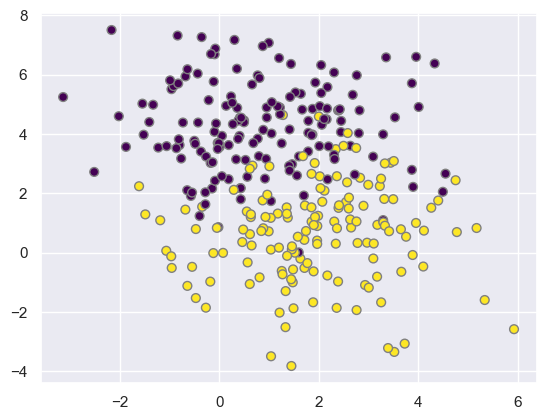

<Figure size 640x480 with 0 Axes>

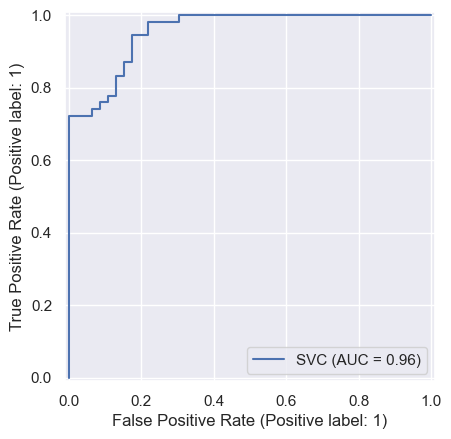

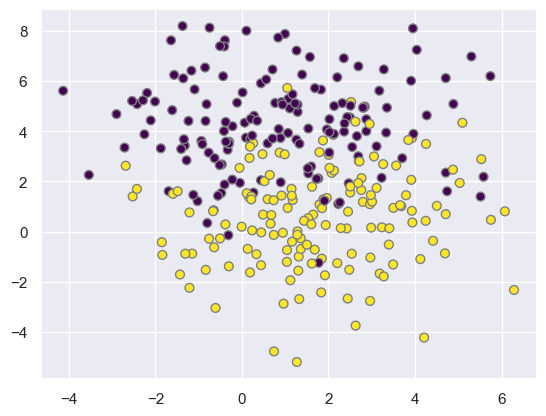

<Figure size 640x480 with 0 Axes>

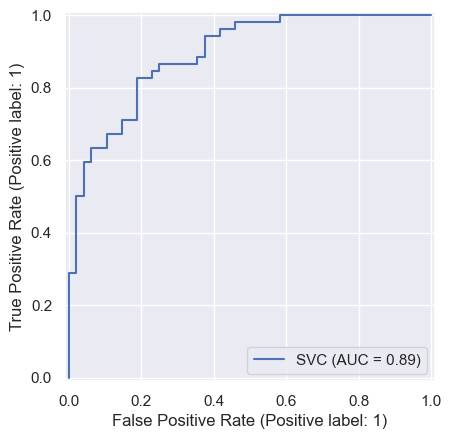

In [7]:
for std in np.linspace(0.2, 2, 5):
    X, y = make_blobs(n_samples=400, centers=2,
                           cluster_std=std, random_state=0)
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model = SVC(kernel='linear').fit(X_train, y_train)
    y_score = model.decision_function(X_test)
    
    # Plot
    plt.figure();
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=40, cmap='viridis', edgecolors='gray');

    # Compute ROC
    plt.figure();
    RocCurveDisplay.from_estimator(model, X_test, y_test);

### Optimal Decision Threshold

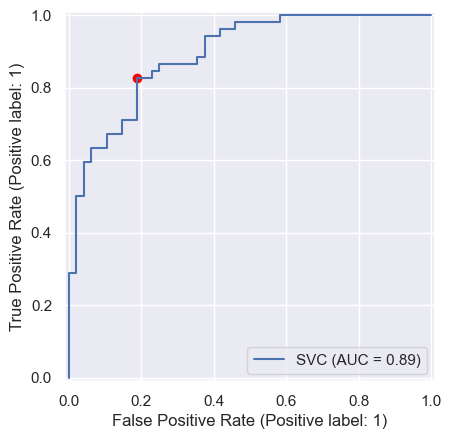

In [8]:
# Get TPR and FPR
fpr, tpr, thresholds = roc_curve(y_test, y_score)
RocCurveDisplay.from_estimator(model, X_test, y_test);

# Calculate Youden's J
J = tpr - fpr
best_threshold_index = np.argmax(J)
best_tpr = tpr[best_threshold_index]
best_fpr = fpr[best_threshold_index]

# Show
plt.scatter(best_fpr, best_tpr, c='red');

In [9]:
# Could be fed into our adjusted_predict function
#adjusted_predict(model, Xtest, tpfp_value=best_tpr)

### Precision Recall Curve

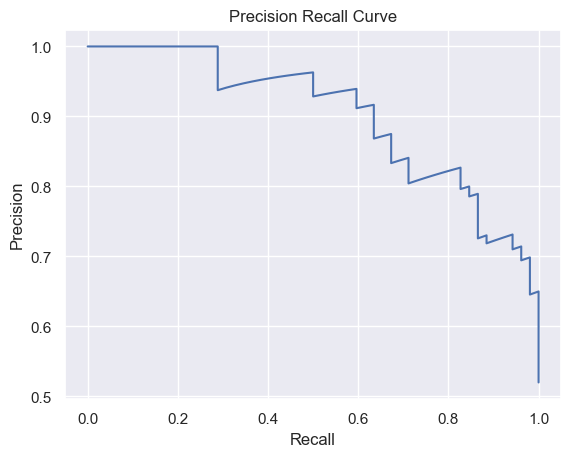

In [10]:
# Get precisions and recalls
precisions, recalls, thresholds = precision_recall_curve(y_test, y_score)

# Show
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve');

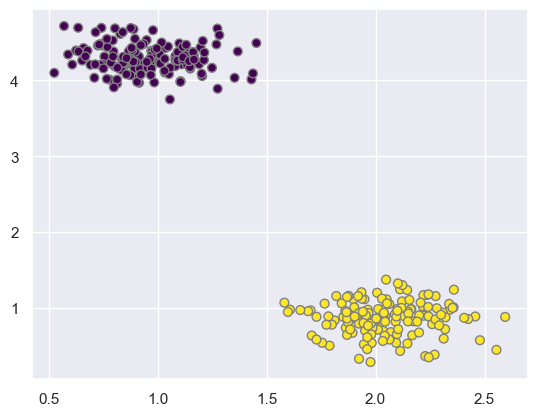

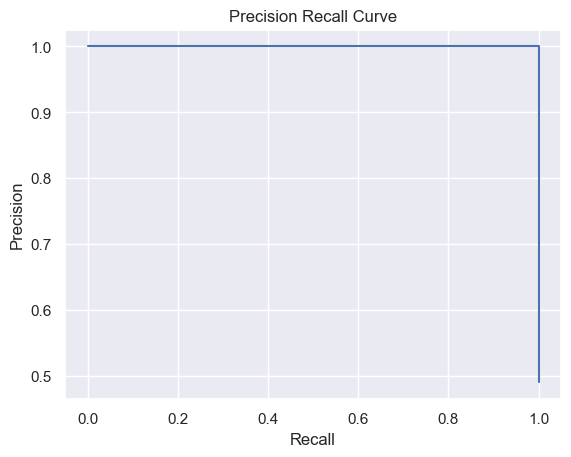

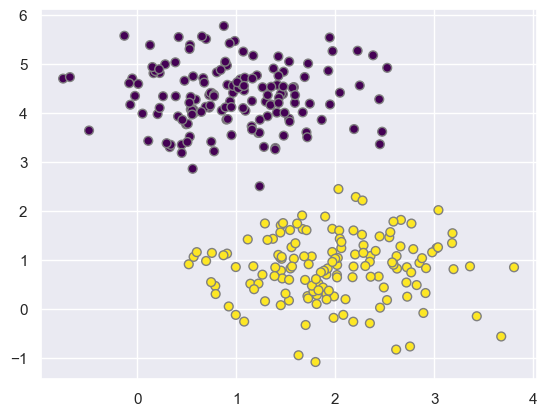

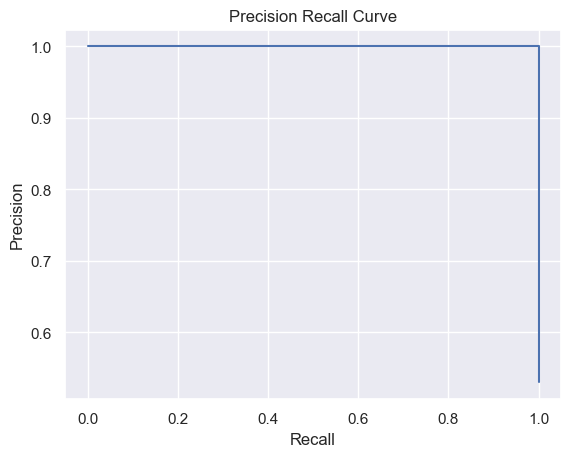

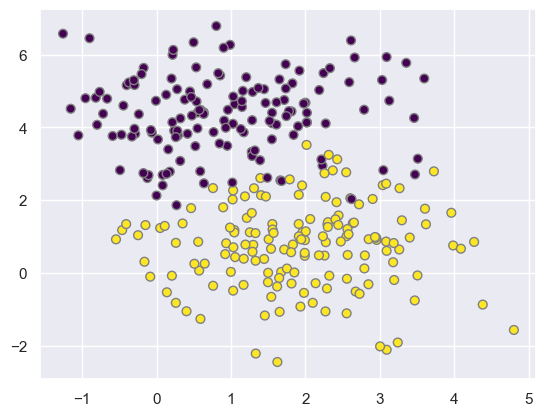

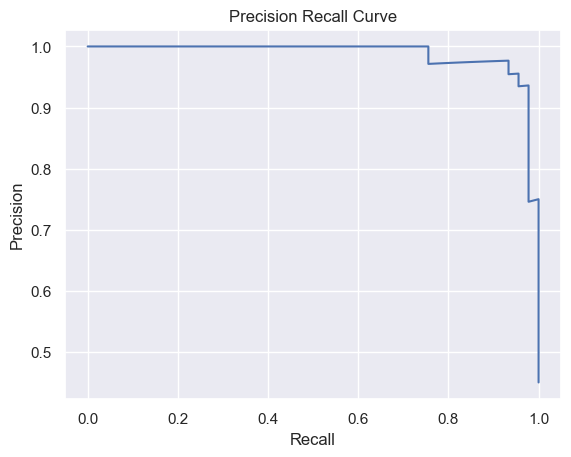

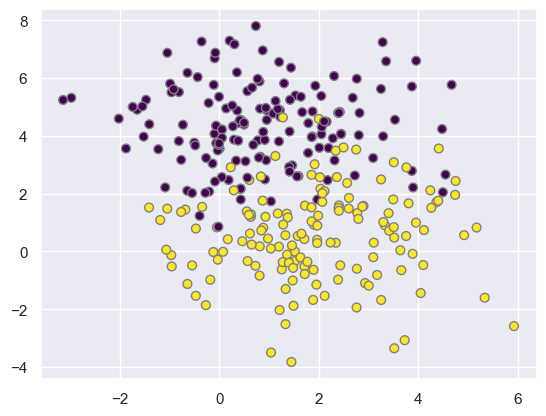

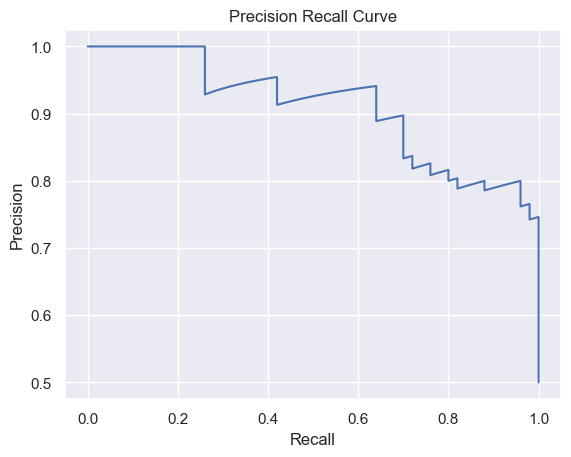

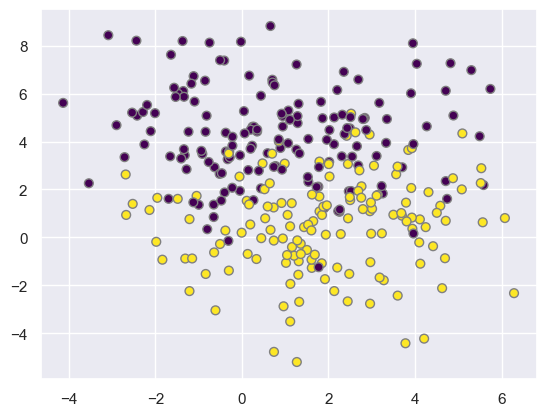

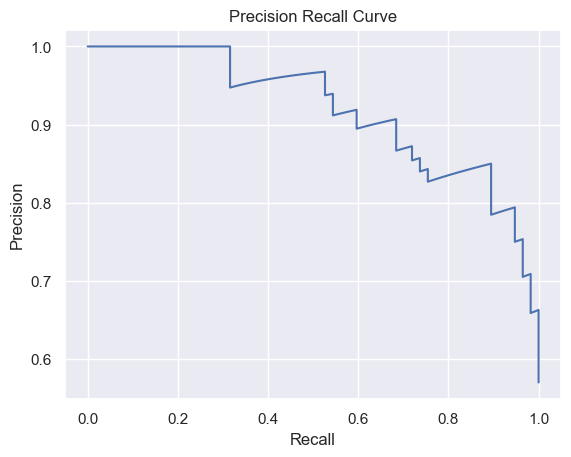

In [11]:
for std in np.linspace(0.2, 2, 5):
    X, y = make_blobs(n_samples=400, centers=2,
                           cluster_std=std, random_state=0)
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model = SVC(kernel='linear').fit(X_train, y_train)
    y_score = model.decision_function(X_test)
    
    # Plot
    plt.figure();
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=40, cmap='viridis', edgecolors='gray');

    # Compute ROC
    plt.figure();
    
    # Get precisions and recalls
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_score)

    # Show
    plt.plot(recalls, precisions)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision Recall Curve');

### Multi-class ROC

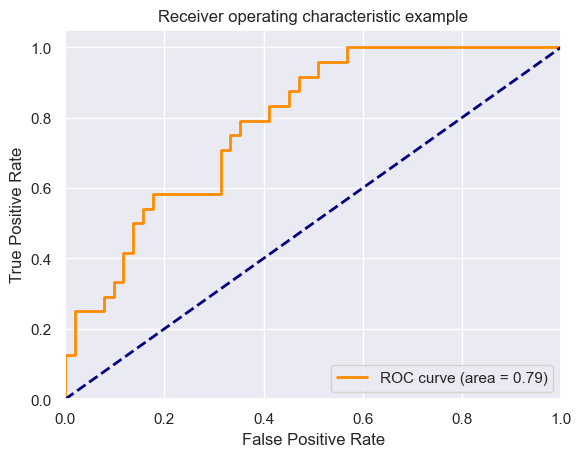

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

# Import some data to play with
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Binarize the output
y = label_binarize(y, classes=[0, 1, 2])
n_classes = y.shape[1]

# Add noisy features to make the problem harder
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]

# shuffle and split training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Learn to predict each class against the other
classifier = OneVsRestClassifier(
    svm.SVC(kernel="linear", probability=True, random_state=random_state)
)
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2
plt.plot(
    fpr[2],
    tpr[2],
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc[2],
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic example")
plt.legend(loc="lower right")
plt.show()

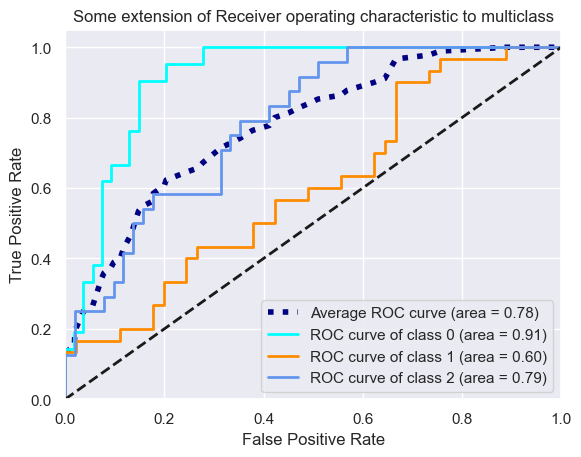

In [13]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
'''
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)
'''
plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="Average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()